1. Objetivo del Modelo de Datos
Este proceso de ETL (Extracción, Transformación y Limpieza) tiene como propósito consolidar un modelo de datos unificado que integra la acción del precio y volumen temporal de criptomonedas (Bitcoin, Ethereum, Solana) junto con indicadores macroeconómicos tradicionales (S&P 500, Índice del dólar DXY). Esta estructura servirá como una base sólida para explorar patrones de comportamiento y correlaciones entre los activos descentralizados y la economía tradicional.

In [2]:
#Instalamos librería yfinance para acceder a los servidores de yahoo finance
%pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\juan_\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


2. Fuentes de Datos y Extracción
Los datos históricos abarcan un período de 730 días y se han extraído automatizadamente mediante la librería yfinance desde los servidores de Yahoo Finance:

- Fuente 1 (Criptomonedas): Extraída con una granularidad temporal de 1 hora. Activos incluidos: BTC-USD, ETH-USD, SOL-USD.

- Fuente 2 (Mercado Tradicional/Macro): Extraída con una granularidad temporal diaria. Activos incluidos: S&P 500 (^GSPC) y US Dollar Index (DX-Y.NYB).

In [4]:
import yfinance as yf
import pandas as pd
import os

# 2.1. Aseguramos que la carpeta existe y obtenemos datos de las diferentes fuentes.
os.makedirs('../datos/raw', exist_ok=True)


# ==========================================
# FUENTE 1: DATOS CRIPTO DIARIOS
# ==========================================
fecha_inicio = '2021-01-01'

print("Descargando datos de Cripto")
tickers_cripto = {'BTC-USD': 'Bitcoin', 'ETH-USD': 'Ethereum', 'SOL-USD': 'Solana'}
lista_df_cripto = []

for ticker, nombre in tickers_cripto.items():
    # Descargamos los últimos 730 días en velas de 1 hora
    df = yf.download(ticker, start=fecha_inicio, interval='1d')
    if isinstance(df.columns, pd.MultiIndex):
       df.columns = df.columns.droplevel(1)

    df['Activo'] = nombre
    lista_df_cripto.append(df)

# Unificamos y guardamos la Fuente 1
df_cripto_total = pd.concat(lista_df_cripto)
df_cripto_total.to_csv('../datos/raw/fuente1_cripto_1d.csv')
print(f"Fuente 1 guardada con {len(df_cripto_total)} filas.")

# ==========================================
# FUENTE 2: DATOS MACRO DIARIOS
# ==========================================
print("Descargando datos Macroeconómicos")
tickers_macro = {'^GSPC': 'S&P_500', 'DX-Y.NYB': 'DXY'}
lista_df_macro = []

for ticker, nombre in tickers_macro.items():
    # Descargamos los mismos últimos 730 días en velas diarias
    df = yf.download(ticker, start=fecha_inicio, interval='1d')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
        
    df['Activo'] = nombre
    lista_df_macro.append(df)

# Unificamos y guardamos la Fuente 2
df_macro_total = pd.concat(lista_df_macro)
df_macro_total.to_csv('../datos/raw/fuente2_macro_diario.csv')
print(f"Fuente 2 guardada con {len(df_macro_total)} filas.")


Descargando datos de Cripto


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Fuente 1 guardada con 6300 filas.
Descargando datos Macroeconómicos


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Fuente 2 guardada con 2888 filas.


3. Transformación, Limpieza y Reglas de Negocio
Para asegurar la calidad del modelo de datos y la coherencia en las futuras medidas DAX y visualizaciones, se aplicarán las siguientes transformaciones en Python (Pandas):

- Sincronización Temporal: Se normaliza la columna horaria de los activos cripto para extraer únicamente la fecha, lo que nos va a permitir un cruce relacional exacto con los datos macroeconómicos diarios.

- Tratamiento de Gaps de Mercado (Valores Nulos): Dado que el mercado tradicional cierra los fines de semana y días festivos, los valores nulos generados en los indicadores macro se rellenarán lógicamente utilizando el último valor conocido registrado (forward fill) y, para casos en el límite inferior, el valor posterior (backward fill).

- Ingeniería de Variables: Vamos a enriquecer el modelo creando dimensiones temporales clave para el análisis de estacionalidad. Extraeremos automáticamente el Día_Semana, el Mes y una variable booleana Es_FinDeSemana.

- Limpieza de Ruido: Eliminaremos columnas redundantes (Adj Close, Unnamed) garantizando un dataset optimizado. El resultado es una tabla maestra estructurada con 88.441 filas, 29 columnas y 0 valores nulos.

In [5]:
# 3.1. Cargar los datos
import pandas as pd
df_cripto = pd.read_csv('../datos/raw/fuente1_cripto_1d.csv')
df_macro = pd.read_csv('../datos/raw/fuente2_macro_diario.csv')

# 3.2. Renombramos la primera columna de ambos para que se llamen exactamente igual
df_cripto.rename(columns={df_cripto.columns[0]: 'Fecha_Hora'}, inplace=True)
df_macro.rename(columns={df_macro.columns[0]: 'Fecha_Hora'}, inplace=True)

# 3.3. Convertir a formato oficial de tiempo (datetime)
df_cripto['Fecha_Hora'] = pd.to_datetime(df_cripto['Fecha_Hora'], errors='coerce', utc=True)
df_macro['Fecha_Hora'] = pd.to_datetime(df_macro['Fecha_Hora'], errors='coerce', utc=True)

# 3.4. Eliminamos posibles filas vacías
df_cripto = df_cripto.dropna(subset=['Fecha_Hora'])
df_macro = df_macro.dropna(subset=['Fecha_Hora'])

# 3.5. Usamos CONCAT para apilar los datos uno debajo del otro
df_maestro = pd.concat([df_cripto, df_macro], ignore_index=True)

# 3.6. Creamos la columna de fecha normalizada para usarla más adelante en Power BI 
df_maestro['Fecha_Diaria'] = df_maestro['Fecha_Hora'].dt.normalize()

# 3.7. Comprobación del resultado
print(f"✅ Dataset apilado con éxito. Filas totales: {len(df_maestro)} | Columnas totales: {len(df_maestro.columns)}")
display(df_maestro)




✅ Dataset apilado con éxito. Filas totales: 9188 | Columnas totales: 8


,Fecha_Hora,Close,High,Low,Open,Volume,Activo,Fecha_Diaria
0,2021-01-01 00:00:00+00:00,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,Bitcoin,2021-01-01 00:00:00+00:00
1,2021-01-02 00:00:00+00:00,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,Bitcoin,2021-01-02 00:00:00+00:00
2,2021-01-03 00:00:00+00:00,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,Bitcoin,2021-01-03 00:00:00+00:00
3,2021-01-04 00:00:00+00:00,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,Bitcoin,2021-01-04 00:00:00+00:00
4,2021-01-05 00:00:00+00:00,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,Bitcoin,2021-01-05 00:00:00+00:00
...,...,...,...,...,...,...,...,...
9183,2026-09-25 00:00:00+00:00,100.970001,101.309998,100.870003,101.269997,0,DXY,2026-09-25 00:00:00+00:00
9184,2026-09-28 00:00:00+00:00,101.199997,101.309998,100.980003,101.099998,0,DXY,2026-09-28 00:00:00+00:00
9185,2026-09-29 00:00:00+00:00,101.370003,101.610001,101.180000,101.190002,0,DXY,2026-09-29 00:00:00+00:00
9186,2026-09-30 00:00:00+00:00,101.449997,101.529999,101.029999,101.410004,0,DXY,2026-09-30 00:00:00+00:00


In [6]:
# 3.5. Rellenamos los valores nulos del mercado tradicional en fines de semana o festivos
# Ordenamos por fecha primero
df_maestro = df_maestro.sort_values('Fecha_Hora')

# 3.6. Extraemos información útil de la fecha
df_maestro['Dia_Semana'] = df_maestro['Fecha_Hora'].dt.day_name()
df_maestro['Mes'] = df_maestro['Fecha_Hora'].dt.month_name()
df_maestro['Es_FinDeSemana'] = df_maestro['Fecha_Hora'].dt.dayofweek >= 5

# 3.7. Limpieza de columnas basura
# Eliminamos columnas repetidas o que no aportan valor
columnas_a_borrar = [col for col in df_maestro.columns if 'Adj Close' in col or 'Unnamed' in col]
df_maestro = df_maestro.drop(columns=columnas_a_borrar)

# 3.8. Comprobamos los nulos para confirmar que todo está limpio
nulos_totales = df_maestro.isnull().sum().sum()
print(f"Limpieza completada. Total de valores nulos en el dataset: {nulos_totales}")

Limpieza completada. Total de valores nulos en el dataset: 0


4. Resumen Estadístico
- El análisis descriptivo inicial confirma la correcta integridad del dataset maestro. Pasamos a calcular los estadísticos principales (medias, desviaciones estándar para medir la volatilidad, mínimos y máximos) para las métricas de apertura, cierre, altos, bajos y volúmenes de todos los activos analizados. El conjunto de datos está listo para ser importado y modelado visualmente.

In [7]:
# 4.1. Pasamos realizar el cálculo de estadísticos descriptivos para buscar patrones del comportamiento de estos activos
# Generamos la transpuesta (.T) para visualizar mejor las métricas clave
estadisticos_principales = df_maestro.describe().T
display(estadisticos_principales[['mean', 'std', 'min', 'max']])

,mean,std,min,max
Close,1.441714e+04,2.685708e+04,1.799275,1.247525e+05
High,1.467712e+04,2.731953e+04,1.859656,1.261981e+05
Low,1.412857e+04,2.634757e+04,1.502038,1.231960e+05
Open,1.441117e+04,2.684827e+04,1.509775,1.247521e+05
Volume,1.416544e+10,1.871946e+10,0.000000,3.509679e+11


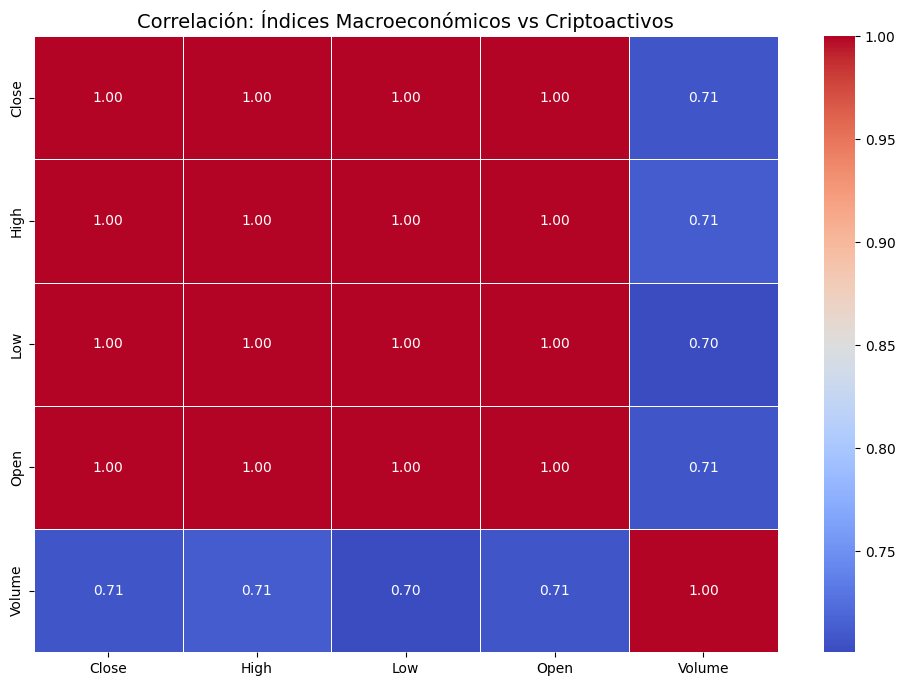

In [8]:
# 4.2. Filtramos exclusivamente las columnas numéricas

import seaborn as sns
import matplotlib.pyplot as plt

columnas_numericas = df_maestro.select_dtypes(include=['float64', 'int64'])
matriz_corr = columnas_numericas.corr()

# 4.2.1. Trazamos el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlación: Índices Macroeconómicos vs Criptoactivos', fontsize=14)
plt.show()

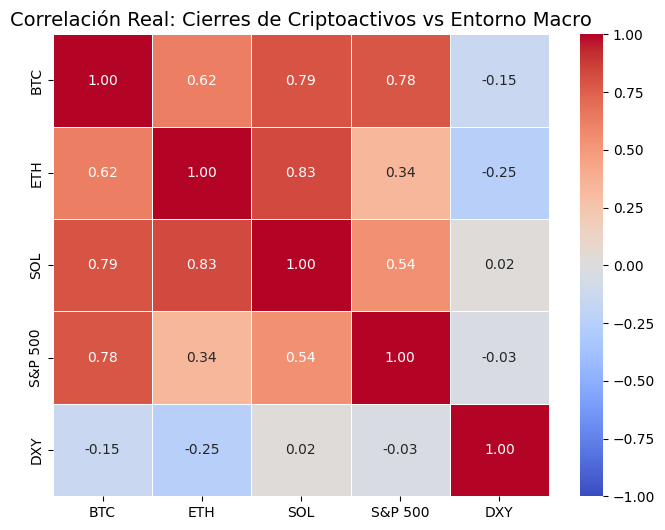

In [9]:
# 4.3. Matriz de Correlación de cierres
import seaborn as sns
import matplotlib.pyplot as plt

# 4.3.1. Creamos una tabla dinámica para aislar los precios de cierre.
# Usamos la fecha como índice, los activos como columnas y el 'Close' como valores.
df_pivot = df_maestro.pivot_table(index='Fecha_Diaria', columns='Activo', values='Close')

# 4.3.2. Seleccionamos y renombramos las columnas para el mapa de calor.
# IMPORTANTE: Asegúrate de que los nombres en 'columnas_origen' coinciden exactamente con 
# los nombres de los activos que descargaste de Yahoo Finance.
columnas_origen = ['Bitcoin', 'Ethereum', 'Solana', 'S&P_500', 'DXY']
df_correlacion = df_pivot[columnas_origen].copy()

# Renombramos para que el gráfico quede limpio
df_correlacion.columns = ['BTC', 'ETH', 'SOL', 'S&P 500', 'DXY']

# 4.3.3. Dibujamos el nuevo mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(df_correlacion.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlación Real: Cierres de Criptoactivos vs Entorno Macro', fontsize=14)
plt.show()

In [10]:
# 5. Exportamos el dataset final
import os

# Aseguramos que la carpeta de datos procesados existe
os.makedirs('../datos/processed', exist_ok=True)

# Guardamos el dataset final limpio sin el índice de Pandas
df_maestro.to_csv('../datos/processed/dataset_final_proyecto.csv', index=False, decimal =',')
print("¡Archivo exportado correctamente!")

¡Archivo exportado correctamente!
